## NBA Predictive Analytics Project (2024-25 Season)

### Source Data

- https://www.kaggle.com/datasets/eduardopalmieri/nba-player-stats-season-2425
- NBA - Player Stats - Season 24/25

***

## Background & Context

### Business Context

Minutes played is foundational to scoring opportunity. Understanding this relationship helps quantify player value and performance.

### Research Question

Given the number of minutes an athlete plays, how many points will they score?

### Why This Matters

Minutes played is the foundation for all downstream predictions. You can't accurately predict points without predicting minutes first. This project teaches you to build a rigorous regression model on a real prediction problem.

### Data Dictionary / Column Descriptions

| Column | Description |
|--------|-------------|
| Player | Name of the player. |
| Team | Abbreviation of the player's team. |
| Opp | Abbreviation of the opposing team. |
| Result | Result of the game for the player's team. |
| MinPlay | Minutes played, represented as a float (e.g., `23.5` = 23 minutes and 30 seconds). |
| FG | Field goals made. |
| FGA | Field goal attempts. |
| FG% | Field goal percentage. |
| 3P | 3-point field goals made. |
| 3PA | 3-point field goal attempts. |
| 3P% | 3-point shooting percentage. |
| FT | Free throws made. |
| FTA | Free throw attempts. |
| FT% | Free throw percentage. |
| ORB | Offensive rebounds. |
| DRB | Defensive rebounds. |
| TRB | Total rebounds. |
| AST | Assists. |
| STL | Steals. |
| BLK | Blocks. |
| TOV | Turnovers. |
| PF | Personal fouls. |
| PTS | Total points scored. |
| +/- | Plus/minus, the point differential when the player is on court. |
| GameScore | Game Score, a metric summarizing player performance for the game. |
| Date | Date of the game in `YYYY-MM-DD` format. |

***

## Workflow

### 1. Phase 1: Exploratory Data Analysis (EDA)
- Examine data structure and shape
- Check for missing values and data types
- Visualize distributions of key variables (PTS, MP)
- Look for outliers and anomalies
- Basic summary statistics

### Phase 2: Data Preparation
- Handle missing values
- Remove or flag problematic rows
- Ensure variables are in correct format for modeling

### Phase 3: Linear Regression: Points from Minutes Played
- Fit OLS model: `PTS ~ MP`
- Extract and interpret coefficients
- Examine model summary (R-squared, F-statistic, p-values)

### Phase 4: Model Diagnostics & Assumptions
- Check normality of residuals (Jarque-Bera test, Q-Q plot)
- Examine residual plots
- Assess homoscedasticity
- Identify any violations of assumptions

### Phase 5: Inference & Interpretation
- Confidence intervals on coefficient estimates
- P-values and statistical significance
- Practical interpretation of results

### Phase 6: Predictions & Visualization
- Generate predictions across a range of MP values
- Calculate confidence intervals and prediction intervals
- Create visualization grid showing:
  - Actual data points (scatter)
  - Predicted line (regression line)
  - Confidence interval ribbon
  - Uncertainty bands


### Repeat for Additional Outcomes (Optional)
- Build separate models for: FG, 3P, FT, AST from MP
- Apply same workflow to each

### Summary & Conclusions
- Compare model results across all outcomes
- Discuss findings and patterns

***

<span style="color:#17A697">

## 0. Imports

Lorem ipsum dolor sit amet, consectetur adipiscing.

</span>

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

***

<span style="color:#17A697">

## 1. Exploratory Data Analysis (EDA)

- Examine data structure and shape
- Check for missing values and data types
- Visualize distributions of key variables (PTS, MP)
- Look for outliers and anomalies
- Basic summary statistics

</span>

In [85]:
df = pd.read_csv('/Users/AMann/Desktop/Coding/NBA Prediction/nba_dailyleaders_full_24_25.csv')
df.head(15)

,Player,Tm,Unnamed: 3,Opp,Result,MP,FG,FGA,FG%,3P,...,TRB,AST,STL,BLK,TOV,PF,PTS,+/-,GmSc,Date
0,Jayson Tatum,BOS,NaN,NYK,W,30:18,14,18,0.778,8,...,4,10,1,1,1,1,37,26.0,38.1,2024-10-22
1,Anthony Davis,LAL,NaN,MIN,W,37:35,11,23,0.478,1,...,16,4,1,3,1,1,36,1.0,34.0,2024-10-22
2,Derrick White,BOS,NaN,NYK,W,26:38,8,13,0.615,6,...,3,4,1,0,0,1,24,21.0,22.4,2024-10-22
3,Jrue Holiday,BOS,NaN,NYK,W,30:31,7,9,0.778,4,...,4,4,1,0,0,2,18,23.0,19.5,2024-10-22
4,Miles McBride,NYK,@,BOS,L,25:51,8,10,0.800,4,...,0,2,0,0,1,1,22,-18.0,17.8,2024-10-22
5,Rui Hachimura,LAL,NaN,MIN,W,35:05,7,14,0.500,1,...,5,1,2,1,0,2,18,19.0,15.9,2024-10-22
6,Jaylen Brown,BOS,NaN,NYK,W,29:54,7,18,0.389,5,...,7,1,1,0,1,3,23,23.0,15.6,2024-10-22
7,Rudy Gobert,MIN,@,LAL,L,35:20,5,8,0.625,0,...,14,2,0,1,1,4,13,-10.0,13.9,2024-10-22
8,Julius Randle,MIN,@,LAL,L,34:19,5,10,0.500,1,...,9,4,0,0,2,3,16,2.0,13.7,2024-10-22
9,Al Horford,BOS,NaN,NYK,W,26:05,4,7,0.571,3,...,3,5,1,1,0,2,11,19.0,13.0,2024-10-22


<span style="color:#E2725B">

Data set read in; showing first 15 rows.

</span>


In [96]:
df = df.rename(columns = {'Tm': 'Team', 'MP': 'MinPlay', 'GmSc': 'GameScore'})
df.head()

,Player,Team,Unnamed: 3,Opp,Result,MinPlay,FG,FGA,FG%,3P,...,TRB,AST,STL,BLK,TOV,PF,PTS,+/-,GameScore,Date
0,Jayson Tatum,BOS,NaN,NYK,W,30.300000,14,18,0.778,8,...,4,10,1,1,1,1,37,26.0,38.1,2024-10-22
1,Anthony Davis,LAL,NaN,MIN,W,37.583333,11,23,0.478,1,...,16,4,1,3,1,1,36,1.0,34.0,2024-10-22
2,Derrick White,BOS,NaN,NYK,W,26.633333,8,13,0.615,6,...,3,4,1,0,0,1,24,21.0,22.4,2024-10-22
3,Jrue Holiday,BOS,NaN,NYK,W,30.516667,7,9,0.778,4,...,4,4,1,0,0,2,18,23.0,19.5,2024-10-22
4,Miles McBride,NYK,@,BOS,L,25.850000,8,10,0.800,4,...,0,2,0,0,1,1,22,-18.0,17.8,2024-10-22


<span style="color:#E2725B">

Renaming columns for easier memorization.

</span>


In [44]:
df.shape

(28265, 27)

<span style="color:#E2725B">

There are 28,265 rows and 27 columns.

</span>


In [97]:
df.iloc[:10, :14]

,Player,Team,Unnamed: 3,Opp,Result,MinPlay,FG,FGA,FG%,3P,3PA,3P%,FT,FTA
0,Jayson Tatum,BOS,NaN,NYK,W,30.300000,14,18,0.778,8,11,0.727,1,2
1,Anthony Davis,LAL,NaN,MIN,W,37.583333,11,23,0.478,1,3,0.333,13,15
2,Derrick White,BOS,NaN,NYK,W,26.633333,8,13,0.615,6,10,0.600,2,2
3,Jrue Holiday,BOS,NaN,NYK,W,30.516667,7,9,0.778,4,6,0.667,0,0
4,Miles McBride,NYK,@,BOS,L,25.850000,8,10,0.800,4,5,0.800,2,3
5,Rui Hachimura,LAL,NaN,MIN,W,35.083333,7,14,0.500,1,4,0.250,3,4
6,Jaylen Brown,BOS,NaN,NYK,W,29.900000,7,18,0.389,5,9,0.556,4,4
7,Rudy Gobert,MIN,@,LAL,L,35.333333,5,8,0.625,0,0,NaN,3,4
8,Julius Randle,MIN,@,LAL,L,34.316667,5,10,0.500,1,3,0.333,5,7
9,Al Horford,BOS,NaN,NYK,W,26.083333,4,7,0.571,3,5,0.600,0,0


<span style="color:#E2725B">

First 14 columns.

</span>

In [98]:
df.iloc[:10, 13:]

,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,+/-,GameScore,Date
0,2,0.500,0,4,4,10,1,1,1,1,37,26.0,38.1,2024-10-22
1,15,0.867,3,13,16,4,1,3,1,1,36,1.0,34.0,2024-10-22
2,2,1.000,0,3,3,4,1,0,0,1,24,21.0,22.4,2024-10-22
3,0,NaN,2,2,4,4,1,0,0,2,18,23.0,19.5,2024-10-22
4,3,0.667,0,0,0,2,0,0,1,1,22,-18.0,17.8,2024-10-22
5,4,0.750,3,2,5,1,2,1,0,2,18,19.0,15.9,2024-10-22
6,4,1.000,2,5,7,1,1,0,1,3,23,23.0,15.6,2024-10-22
7,4,0.750,3,11,14,2,0,1,1,4,13,-10.0,13.9,2024-10-22
8,7,0.714,3,6,9,4,0,0,2,3,16,2.0,13.7,2024-10-22
9,0,NaN,0,3,3,5,1,1,0,2,11,19.0,13.0,2024-10-22


<span style="color:#E2725B">

Last 14 columns.

</span>

In [99]:
df.columns

Index(['Player', 'Team', 'Unnamed: 3', 'Opp', 'Result', 'MinPlay', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB',
       'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', '+/-', 'GameScore', 'Date'],
      dtype='str')

<span style="color:#E2725B">

All the columns.

</span>


In [100]:
df.nunique()

Player         569
Team            30
Unnamed: 3       1
Opp             30
Result           2
MinPlay       2700
FG              23
FGA             40
FG%            200
3P              12
3PA             21
3P%             74
FT              22
FTA             25
FT%             73
ORB             14
DRB             22
TRB             27
AST             23
STL              9
BLK             11
TOV             12
PF               7
PTS             60
+/-             98
GameScore      489
Date           214
dtype: int64

<span style="color:#E2725B">

The number of unique values per column.

</span>


In [101]:
df.dtypes

Player            str
Team              str
Unnamed: 3        str
Opp               str
Result            str
MinPlay       float64
FG              int64
FGA             int64
FG%           float64
3P              int64
3PA             int64
3P%           float64
FT              int64
FTA             int64
FT%           float64
ORB             int64
DRB             int64
TRB             int64
AST             int64
STL             int64
BLK             int64
TOV             int64
PF              int64
PTS             int64
+/-           float64
GameScore     float64
Date              str
dtype: object

<span style="color:#E2725B">

The data types for each column.

</span>


In [102]:
def time_to_float(time_string):
    minutes, seconds = time_string.split(':')
    decimal_minutes = float(minutes) + float(seconds) / 60
    return decimal_minutes

In [ ]:
df['MinPlay'] = df['MinPlay'].apply(time_to_float)

<span style="color:#E2725B">

Converting 'MinPlay' (minutes played) from a string to a float.

</span>


In [103]:
df['MinPlay'].dtype

dtype('float64')

<span style="color:#E2725B">

Confirming data type.

</span>


In [104]:
df['MinPlay'].isnull().sum()

np.int64(0)

<span style="color:#E2725B">

Confirming missing values.

</span>


In [105]:
df.isna().sum()

Player            0
Team              0
Unnamed: 3    14208
Opp               0
Result            0
MinPlay           0
FG                0
FGA               0
FG%            1643
3P                0
3PA               0
3P%            5817
FT                0
FTA               0
FT%           12900
ORB               0
DRB               0
TRB               0
AST               0
STL               0
BLK               0
TOV               0
PF                0
PTS               0
+/-              18
GameScore         0
Date              0
dtype: int64

<span style="color:#E2725B">

The number of missing values per column.

</span>


In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28265 entries, 0 to 28264
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Player      28265 non-null  str    
 1   Team        28265 non-null  str    
 2   Unnamed: 3  14057 non-null  str    
 3   Opp         28265 non-null  str    
 4   Result      28265 non-null  str    
 5   MinPlay     28265 non-null  float64
 6   FG          28265 non-null  int64  
 7   FGA         28265 non-null  int64  
 8   FG%         26622 non-null  float64
 9   3P          28265 non-null  int64  
 10  3PA         28265 non-null  int64  
 11  3P%         22448 non-null  float64
 12  FT          28265 non-null  int64  
 13  FTA         28265 non-null  int64  
 14  FT%         15365 non-null  float64
 15  ORB         28265 non-null  int64  
 16  DRB         28265 non-null  int64  
 17  TRB         28265 non-null  int64  
 18  AST         28265 non-null  int64  
 19  STL         28265 non-null  int64  


<span style="color:#E2725B">

Exploratory data.

</span>


In [107]:
df.mean(numeric_only = True)

MinPlay      22.556967
FG            3.879887
FGA           8.319123
FG%           0.455368
3P            1.258270
3PA           3.497400
3P%           0.334707
FT            1.588785
FTA           2.038139
FT%           0.765673
ORB           1.038705
DRB           3.075889
TRB           4.114594
AST           2.457775
STL           0.765151
BLK           0.456536
TOV           1.259544
PF            1.751176
PTS          10.606828
+/-           0.000177
GameScore     8.650670
dtype: float64

<span style="color:#E2725B">

Mean for all continuous variables.

</span>


In [108]:
df.std(numeric_only = True)

MinPlay      10.999814
FG            3.255030
FGA           6.068272
FG%           0.237988
3P            1.525269
3PA           3.146204
3P%           0.283949
FT            2.273846
FTA           2.734015
FT%           0.283624
ORB           1.379611
DRB           2.714491
TRB           3.471946
AST           2.613973
STL           0.989598
BLK           0.819571
TOV           1.415114
PF            1.444915
PTS           8.844302
+/-          11.765434
GameScore     7.842648
dtype: float64

<span style="color:#E2725B">

Standard deviation for all continuous variables.

</span>


In [109]:
df.sem(numeric_only = True)

MinPlay      0.065428
FG           0.019361
FGA          0.036094
FG%          0.001459
3P           0.009072
3PA          0.018714
3P%          0.001895
FT           0.013525
FTA          0.016262
FT%          0.002288
ORB          0.008206
DRB          0.016146
TRB          0.020651
AST          0.015548
STL          0.005886
BLK          0.004875
TOV          0.008417
PF           0.008594
PTS          0.052606
+/-          0.070004
GameScore    0.046649
dtype: float64

<span style="color:#E2725B">

Standard error of the mean for all continuous variables.

</span>


In [115]:
print(df['PTS'].mean())
print(df['PTS'].std())
print(df['PTS'].sem())

10.606828232796746
8.844302357860109
0.05260646099192391


In [126]:
df['PTS'].describe()

count    28265.000000
mean        10.606828
std          8.844302
min          0.000000
25%          4.000000
50%          9.000000
75%         16.000000
max         61.000000
Name: PTS, dtype: float64

<span style="color:#E2725B">

The average number of points per game is 10.6 with the range going from 0 to 61. And the standard deviation is 8-9 so we have most of our data for 'PTS' within the 2 to 19 range. 

</span>


In [116]:
print(df['MinPlay'].mean())
print(df['MinPlay'].std())
print(df['MinPlay'].sem())

22.55696739194528
10.99981413737701
0.06542757923942627


In [127]:
df['MinPlay'].describe()

count    28265.000000
mean        22.556967
std         10.999814
min          0.000000
25%         14.533333
50%         23.666667
75%         31.450000
max         53.166667
Name: MinPlay, dtype: float64

<span style="color:#E2725B">

The average number of minutes played per game is 22.5 with the range going from 0 to 53 (this must account for overtime). And the standard deviation is 11 so we have most of our data for 'MinPlay' within the 11 to ~34 range. This makes sense because people don't normally play all 48 minutes of a match and you have variations in the roles that people play on teams (stars vs role players, etc.).

</span>


In [138]:
df[(df['MinPlay'] > 48)]

,Player,Team,Unnamed: 3,Opp,Result,MinPlay,FG,FGA,FG%,3P,...,TRB,AST,STL,BLK,TOV,PF,PTS,+/-,GameScore,Date
11276,Domantas Sabonis,SAC,NaN,MIA,W,50.483333,7,16,0.438,2,...,18,11,1,3,6,5,21,11.0,22.0,2025-01-06
11298,Tyler Herro,MIA,@,SAC,L,48.866667,11,25,0.440,4,...,7,4,2,0,3,2,26,-6.0,16.4,2025-01-06
11300,Keon Ellis,SAC,NaN,MIA,W,48.516667,6,11,0.545,3,...,8,3,3,1,2,4,17,7.0,16.3,2025-01-06
11308,Malik Monk,SAC,NaN,MIA,W,48.516667,8,25,0.320,1,...,5,6,2,0,1,3,23,7.0,14.6,2025-01-06
12665,Josh Hart,NYK,@,PHI,W,49.416667,4,9,0.444,0,...,17,12,4,0,3,3,10,10.0,20.2,2025-01-15
16371,Devin Booker,PHO,NaN,UTA,W,48.866667,18,33,0.545,3,...,6,11,1,0,4,4,47,7.0,36.0,2025-02-07
17432,James Harden,LAC,@,UTA,W,49.266667,8,19,0.421,5,...,10,7,3,2,3,4,32,11.0,28.4,2025-02-13
24122,Nikola Jokić,DEN,NaN,MIN,L,52.633333,18,29,0.621,6,...,10,10,2,0,4,5,61,2.0,52.7,2025-04-01
24135,Anthony Edwards,MIN,@,DEN,W,50.483333,12,25,0.480,5,...,10,8,1,0,5,4,34,8.0,23.9,2025-04-01
24140,Christian Braun,DEN,NaN,MIN,L,53.166667,8,14,0.571,1,...,12,4,3,0,2,1,18,12.0,20.0,2025-04-01


<span style="color:#E2725B">

Checking the standout athletes who played more than 48 minutes of basketball.

</span>


In [139]:
df[(df['PTS'] > 50)]

,Player,Team,Unnamed: 3,Opp,Result,MinPlay,FG,FGA,FG%,3P,...,TRB,AST,STL,BLK,TOV,PF,PTS,+/-,GameScore,Date
3618,Giannis Antetokounmpo,MIL,NaN,DET,W,43.633333,21,34,0.618,1,...,14,7,2,3,3,1,59,7.0,54.2,2024-11-13
3863,De'Aaron Fox,SAC,NaN,MIN,L,44.483333,22,35,0.629,6,...,3,7,3,1,6,3,60,1.0,47.0,2024-11-15
7368,Nikola Jokić,DEN,@,WAS,L,38.650000,22,39,0.564,3,...,16,8,1,0,5,5,56,-1.0,43.1,2024-12-07
9863,Jalen Brunson,NYK,@,WAS,W,44.000000,18,31,0.581,3,...,3,9,0,0,3,1,55,1.0,43.9,2024-12-28
10955,Anthony Edwards,MIN,@,DET,L,44.450000,16,31,0.516,10,...,6,2,0,0,6,4,53,-3.0,33.3,2025-01-04
13752,Shai Gilgeous-Alexander,OKC,NaN,UTA,W,37.466667,17,35,0.486,3,...,8,5,3,2,3,3,54,9.0,43.2,2025-01-22
14849,Shai Gilgeous-Alexander,OKC,@,GSW,L,39.100000,16,29,0.552,2,...,3,4,1,0,3,4,52,1.0,37.0,2025-01-29
17115,Jamal Murray,DEN,NaN,POR,W,42.216667,20,36,0.556,7,...,4,5,2,0,2,3,55,26.0,41.7,2025-02-12
18782,Stephen Curry,GSW,@,ORL,W,34.300000,16,25,0.640,12,...,4,3,2,0,4,0,56,15.0,46.2,2025-02-27
19409,Shai Gilgeous-Alexander,OKC,NaN,HOU,W,35.633333,18,30,0.600,5,...,5,7,1,1,2,1,51,6.0,43.7,2025-03-03


<span style="color:#E2725B">

Checking the standout athletes who scored more than 50 points per game.

</span>


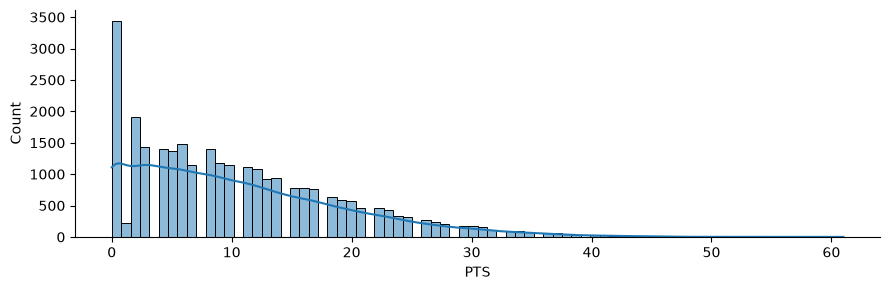

In [120]:
sns.displot(data = df, x = 'PTS', kind = 'hist', kde = True,  height = 3, aspect = 3)
plt.show()

<span style="color:#E2725B">

Makes sense for it to be right-skewed with many players scoring 0 to few points and few players scoring many points. Matches my assumptions.

</span>

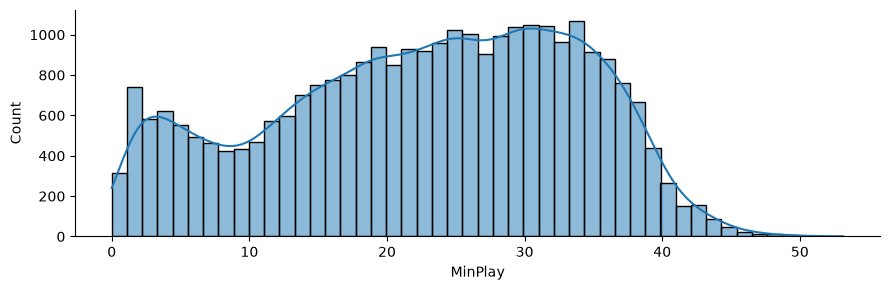

In [121]:
sns.displot(data = df, x = 'MinPlay', kind = 'hist', kde = True,  height = 3, aspect = 3)
plt.show()

<span style="color:#E2725B">

Because there are bench players are starters, I think it makes sense that most people are playing around 15-35 minutes. It's likely not desirable to have a team where many people have to be benched a lot, though the NBA does tend to have stars and smaller trios of athletes who lead teams.

</span>

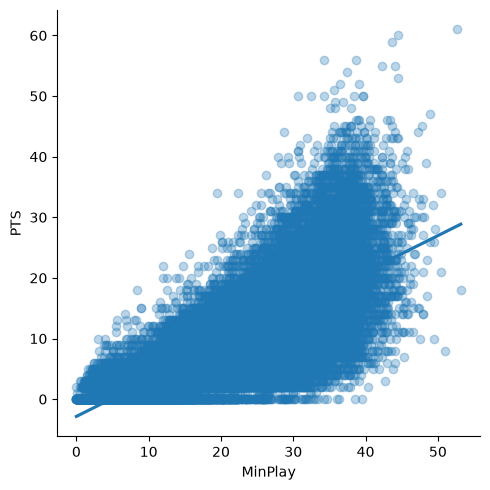

In [134]:
sns.lmplot(data = df, x = 'MinPlay', y = 'PTS', scatter_kws={'alpha': 0.3})
plt.show()

<span style="color:#E2725B">

Since there is a large sample size (over 28,000), this scatterplot is very hard to read but there are some ideas we're getting here:
- There is a positive correlation between minutes played and points scored. Makes sense. The more time you have on the court, the more chances you have for buckets.
- There are some outliers here which we affirmed above, looking at the upper end of the data for minutes and points.

</span>


***

## Hypothesis & Assumptions

<span style="color:#E2725B">

#### Hypothesis
There is a positive linear relationship between minutes played and points scored. For every additional minute played, a player scores approximately X more points (to be estimated from the model).

#### Assumptions
- Linear relationship between MP and PTS
- Observations are independent
- Errors are normally distributed around the regression line
- Constant variance across all levels of minutes (homoscedasticity)

#### Limitations & Notes
- Linearity may not hold perfectly; residual plots will reveal any curvature or threshold effects
- Independence assumption is imperfect: the same players appear across multiple games, and injuries/performance streaks carry over between games. With a large sample size (n=28k), this violation is unlikely to severely bias results, but it warrants acknowledgment
- Relationship is simplified; individual player talent, role, and team context are captured in residuals, not modeled explicitly

</span>

***

<span style="color:#17A697">

## 2. Data Preparation

- Handle missing values
- Remove or flag problematic rows
- Ensure variables are in correct format for modeling

</span>

In [111]:
df.columns

Index(['Player', 'Team', 'Unnamed: 3', 'Opp', 'Result', 'MinPlay', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB',
       'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', '+/-', 'GameScore', 'Date'],
      dtype='str')

In [148]:
points_minutes_model = ['Player', 'Team', 'Result', 'MinPlay', 'FG', 'FGA', 'PTS', 'Date', 'GameScore', 'Date']
model = df[points_minutes_model]
model.head(10)

,Player,Team,Result,MinPlay,FG,FGA,PTS,Date,GameScore,Date
0,Jayson Tatum,BOS,W,30.300000,14,18,37,2024-10-22,38.1,2024-10-22
1,Anthony Davis,LAL,W,37.583333,11,23,36,2024-10-22,34.0,2024-10-22
2,Derrick White,BOS,W,26.633333,8,13,24,2024-10-22,22.4,2024-10-22
3,Jrue Holiday,BOS,W,30.516667,7,9,18,2024-10-22,19.5,2024-10-22
4,Miles McBride,NYK,L,25.850000,8,10,22,2024-10-22,17.8,2024-10-22
5,Rui Hachimura,LAL,W,35.083333,7,14,18,2024-10-22,15.9,2024-10-22
6,Jaylen Brown,BOS,W,29.900000,7,18,23,2024-10-22,15.6,2024-10-22
7,Rudy Gobert,MIN,L,35.333333,5,8,13,2024-10-22,13.9,2024-10-22
8,Julius Randle,MIN,L,34.316667,5,10,16,2024-10-22,13.7,2024-10-22
9,Al Horford,BOS,W,26.083333,4,7,11,2024-10-22,13.0,2024-10-22


<span style="color:#E2725B">

Focusing the dataframe for research goals.

</span>

In [149]:
model.isna().sum()

Player       0
Team         0
Result       0
MinPlay      0
FG           0
FGA          0
PTS          0
Date         0
GameScore    0
Date         0
dtype: int64

<span style="color:#E2725B">

Focusing the dataframe for research goals.

</span>

In [150]:
print((df['PTS'] == 0).sum())
print((df['MinPlay'] == 0).sum())

3441
11


In [151]:
model = model[model['MinPlay'] != 0]

In [152]:
model.shape

(28254, 10)

***

<span style="color:#17A697">

## 3. Linear Regression: Points from Minutes Played

- Fit OLS model: `PTS ~ MP`
- Extract and interpret coefficients
- Examine model summary (R-squared, F-statistic, p-values)

</span>

***

<span style="color:#17A697">

## 4. Model Diagnostics & Assumptions

- Check normality of residuals (Jarque-Bera test, Q-Q plot)
- Examine residual plots
- Assess homoscedasticity
- Identify any violations of assumptions

</span>

***

<span style="color:#17A697">

## 5. Inference & Interpretation
- Confidence intervals on coefficient estimates
- P-values and statistical significance
- Practical interpretation of results

</span>

***

<span style="color:#17A697">

## 6. Predictions & Visualization

- Generate predictions across a range of MP values
- Calculate confidence intervals and prediction intervals
- Create visualization grid showing:
  - Actual data points (scatter)
  - Predicted line (regression line)
  - Confidence interval ribbon
  - Uncertainty bands


</span>

***

<span style="color:#17A697">

## 7. Repeat for Additional Outcomes (Optional)

- Build separate models for: FG, 3P, FT, AST from MP
- Apply same workflow to each

</span>

***

<span style="color:#17A697">

## 8. Summary & Conclusions

- Compare model results across all outcomes
- Discuss findings and patterns

</span>

***

## Formatting Styles


<span style="color:#17A697">

### Section

Lorem ipsum dolor sit amet, consectetur adipiscing.

</span>



<span style="color:#E2725B">

#### Subsection

Lorem ipsum dolor sit amet, consectetur adipiscing.

</span>

